In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split

In [2]:
path = r'/Users/artoe/Documents/DataAnalytics/Machine Learning With Python/Achievement 2/data'

In [3]:
#import cleaned, unscaled weather data
weather = pd.read_csv(os.path.join(path, 'weather_cleaned.csv'), index_col = False)

In [4]:
#import pleasant weather data
pleasant = pd.read_csv(os.path.join(path, 'Pleasant_Weather.csv'), index_col = False)

In [5]:
weather.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,MUNCHENB_pressure,STOCKHOLM_humidity
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,1.0003,0.45,0.34,4.7,8.5,6.0,10.9,8,1.0304,0.98
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,1.0007,0.25,0.84,0.7,8.9,5.6,12.1,8,1.0292,0.62
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,1.0096,0.17,0.08,0.1,10.5,8.1,12.9,7,1.0320,0.69
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,1.0184,0.13,0.98,0.0,7.4,7.3,10.6,8,1.0443,0.98
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,1.0328,0.46,0.00,5.7,5.7,3.0,8.4,7,1.0430,0.96


In [6]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
#extracting weather data from 2010-2020
weather2010 = weather[weather['DATE'].astype(str).str.startswith('201')] 

In [8]:
#check range
print('start date:', weather2010['DATE'].head(1))
print('end date:', weather2010['DATE'].tail(1))

start date: 18263    20100101
Name: DATE, dtype: int64
end date: 21914    20191231
Name: DATE, dtype: int64


In [9]:
#extracting pleasant weather data from 2010-2020
pleasant2010 = pleasant[pleasant['DATE'].astype(str).str.startswith('201')] 

In [10]:
#check range
print('start date:', pleasant2010['DATE'].head(1))
print('end date:', pleasant2010['DATE'].tail(1))

start date: 18263    20100101
Name: DATE, dtype: int64
end date: 21914    20191231
Name: DATE, dtype: int64


In [11]:
#drop date and month columns
weather2010.drop(['DATE', 'MONTH'], axis=1, inplace=True)

C:\Users\artoe\AppData\Local\Temp\ipykernel_17228\4062150102.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather2010.drop(['DATE', 'MONTH'], axis=1, inplace=True)


In [12]:
pleasant2010.drop(['DATE'], axis=1, inplace=True)

C:\Users\artoe\AppData\Local\Temp\ipykernel_17228\1151556522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pleasant2010.drop(['DATE'], axis=1, inplace=True)


In [13]:
weather2010.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,MUNCHENB_pressure,STOCKHOLM_humidity
18263,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,4.8,6,...,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0,8,1.0054,0.76
18264,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,0.4,8,...,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2,7,1.0250,0.74
18265,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,1.1,7,...,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1,8,1.0404,0.84
18266,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,-3.1,2,...,1.0219,0.48,0.51,6.5,3.7,1.3,3.8,7,1.0316,0.89
18267,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,-1.5,6,...,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4,7,1.0206,0.78


In [14]:
pleasant2010.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
weather2010.shape

(3652, 135)

In [16]:
pleasant2010.shape

(3652, 15)

In [17]:
#identify X and y
X = weather2010
y = pleasant2010

In [18]:
y.shape

(3652, 15)

In [19]:
y

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [20]:
#we need to reshape y into a single value representation
y = pleasant2010.sum(axis=1)

In [21]:
y.head(30)

18263    0
18264    0
18265    0
18266    0
18267    0
18268    0
18269    0
18270    0
18271    0
18272    0
18273    0
18274    0
18275    0
18276    0
18277    0
18278    0
18279    0
18280    0
18281    0
18282    0
18283    0
18284    0
18285    0
18286    0
18287    0
18288    0
18289    0
18290    0
18291    0
18292    0
dtype: int64

In [22]:
print('y shape', y.shape)
print('y unique values', y.unique())

y shape (3652,)
y unique values [ 0  1  3  2  5  4  6  9  7 10  8 11 12 13]


In [23]:
#the unique values are the number of pleasant weather reports on that day. we will define this as a list to apply as a class later
pleasantdays = ['0','1','2','3','4','5','6','7','8','9','10','11','12','13']

In [24]:
#convert X to array
X = np.array(X)

In [25]:
#check shape once more
print('X shape', X.shape)
print('y shape', y.shape)

X shape (3652, 135)
y shape (3652,)


In [26]:
#split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [27]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739,)
(913, 135) (913,)


In [28]:
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100, random_state=42, bootstrap=False) 

In [29]:
#training model on the train dataset
clf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=False, random_state=42)

In [30]:
# performing predictions on the test dataset
y_pred = clf.predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.5575027382256298


[Text(0.22376595822546844, 0.975, 'x[121] <= 3.25\ngini = 0.827\nsamples = 2739\nvalue = [1008.0, 265.0, 169.0, 177.0, 153.0, 171.0, 156.0, 143.0\n127.0, 129.0, 125.0, 76.0, 33.0, 7.0]\nclass = 0'),
 Text(0.08221946322907861, 0.925, 'x[86] <= 12.25\ngini = 0.413\nsamples = 1155\nvalue = [871.0, 138.0, 53.0, 36.0, 16.0, 15.0, 9.0, 3.0, 4.0\n7.0, 3.0, 0.0, 0.0, 0.0]\nclass = 0'),
 Text(0.15299271072727352, 0.95, 'True  '),
 Text(0.04719639335023951, 0.875, 'x[79] <= 13.55\ngini = 0.172\nsamples = 919\nvalue = [835, 40, 16, 12, 4, 7, 2, 0, 2, 1, 0, 0, 0\n0]\nclass = 0'),
 Text(0.027261200338123414, 0.825, 'x[103] <= 1.55\ngini = 0.103\nsamples = 859\nvalue = [813, 29, 12, 3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.019089884474499857, 0.775, 'x[16] <= 14.05\ngini = 0.039\nsamples = 664\nvalue = [651, 8, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.015638207945900255, 0.725, 'x[26] <= 17.9\ngini = 0.033\nsamples = 661\nvalue = [650, 6, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

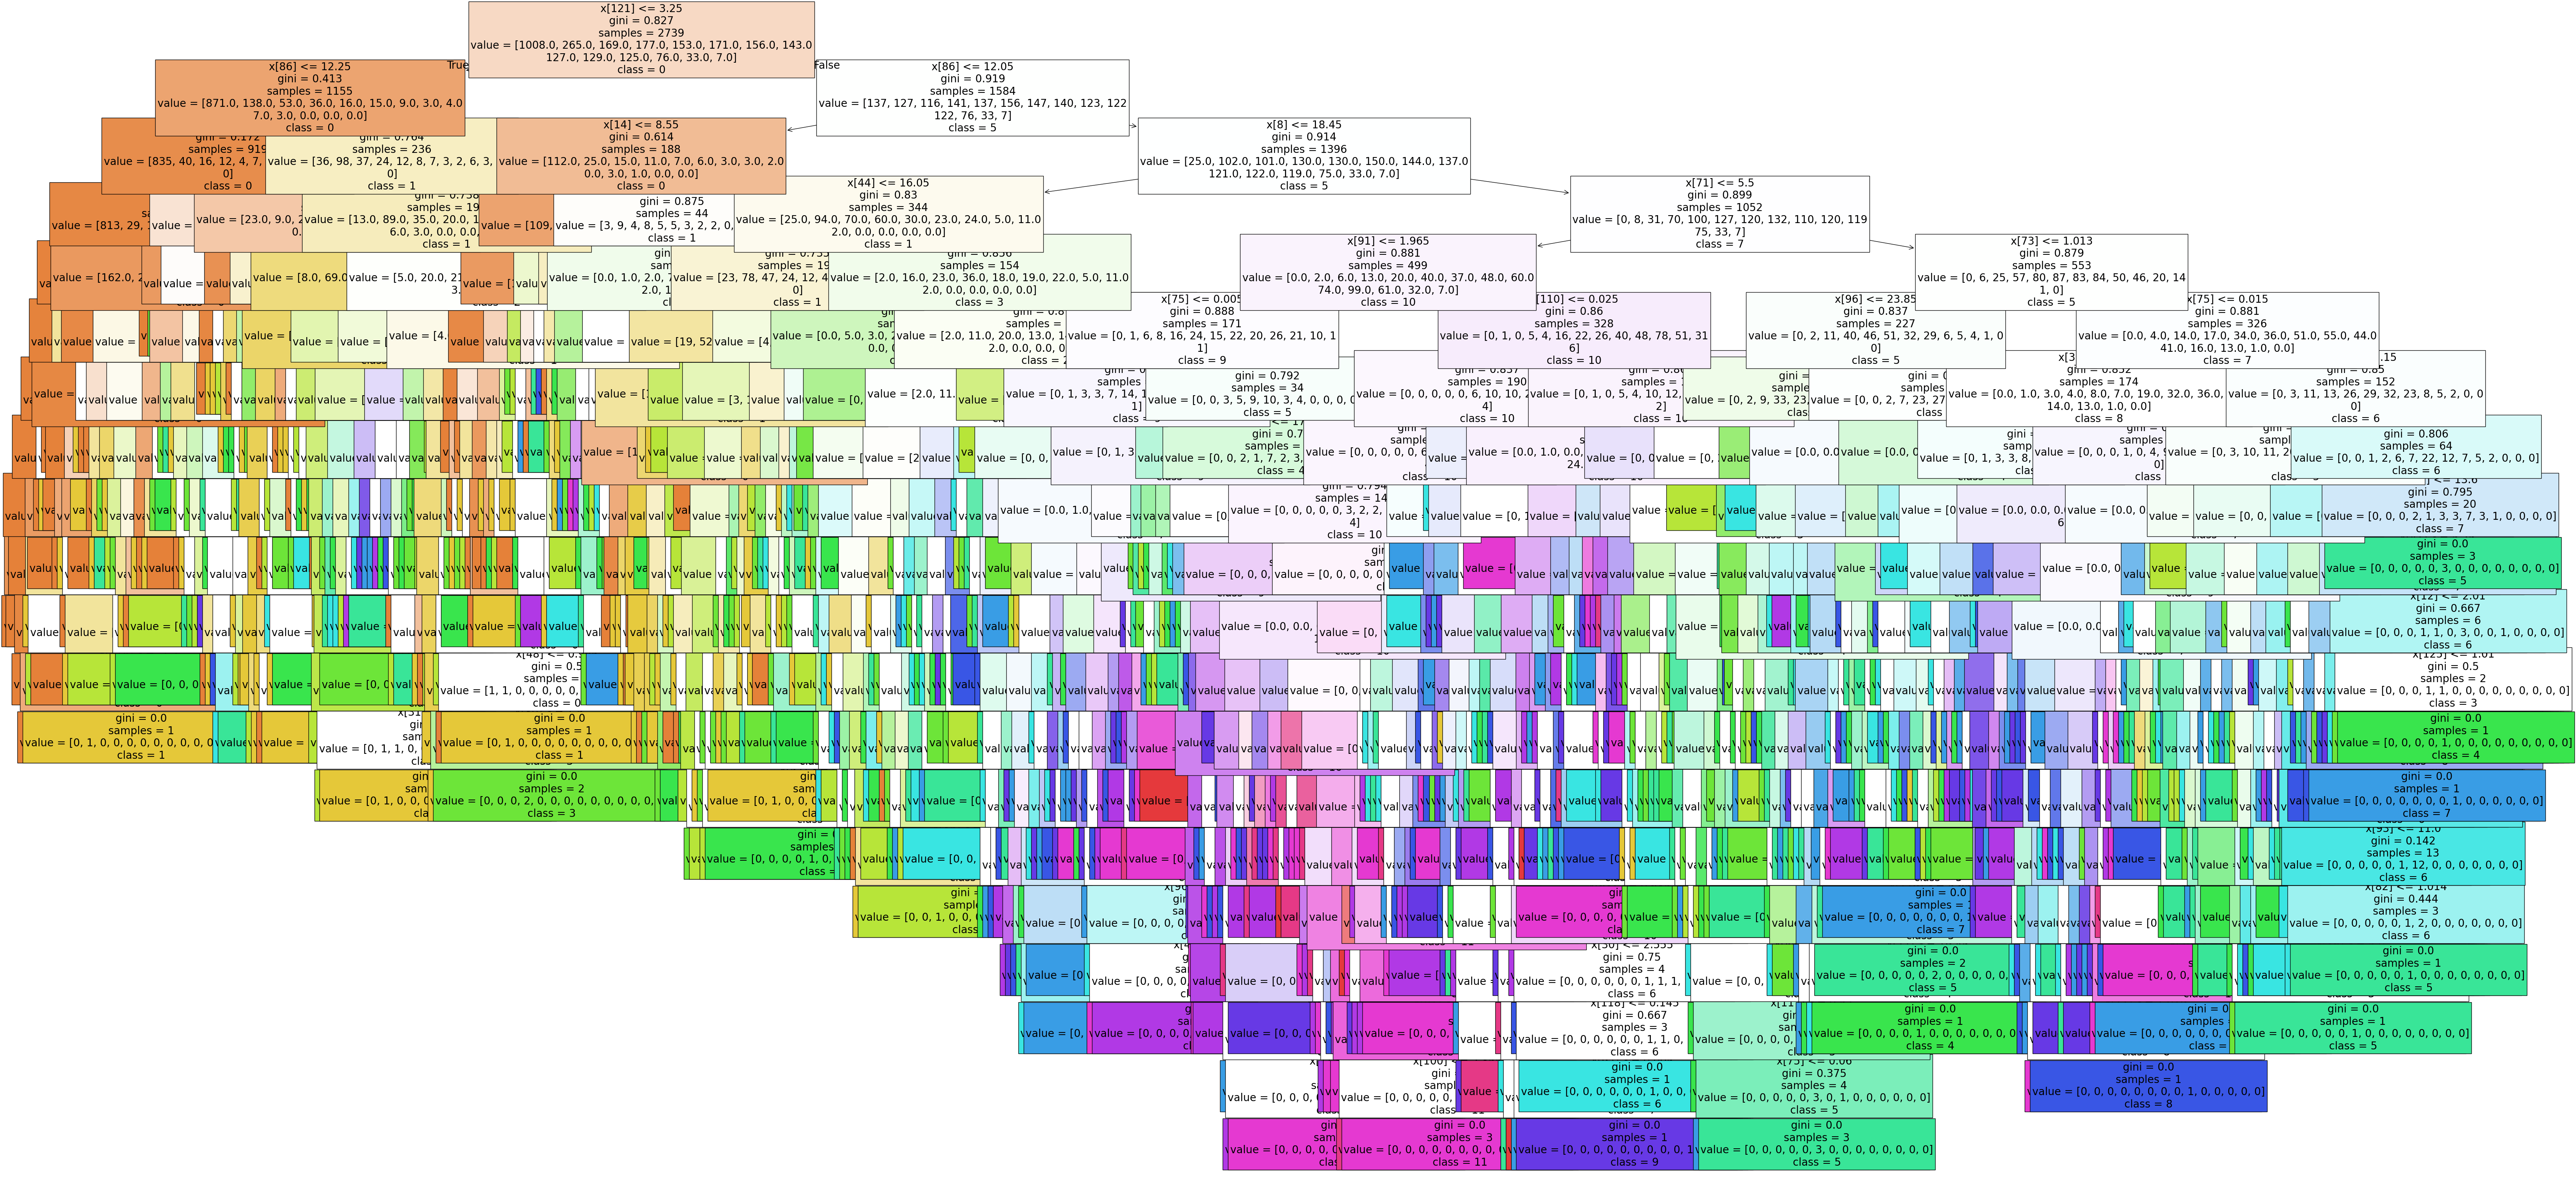

In [31]:
fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[15], fontsize = 20, class_names=pleasantdays, filled=True)

#### this model is 55.1% accurate

In [33]:
fig.savefig(f"{path}/2.3forest1_redo.png")

### Feature importances

#### Importance of Weather Conditions on Random Forest

In [36]:
newarray = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray

(135,)


array([4.06266444e-03, 5.61624892e-03, 5.43376291e-03, 6.55589695e-03,
       7.05110130e-03, 8.24654279e-03, 1.69953855e-02, 4.94338619e-03,
       1.75047784e-02, 4.22889839e-03, 5.69198223e-03, 7.05070168e-03,
       5.02405936e-03, 4.36299653e-03, 5.48287758e-03, 1.20139912e-02,
       8.19996932e-03, 1.44127757e-02, 4.19436992e-04, 0.00000000e+00,
       0.00000000e+00, 2.01873460e-03, 4.33304740e-03, 2.17648728e-03,
       2.52822023e-02, 9.65458967e-03, 2.81936550e-02, 3.84966307e-03,
       4.97781490e-03, 6.77115352e-03, 6.29739263e-03, 6.84121763e-03,
       6.46072733e-03, 1.21814160e-02, 5.16345974e-03, 2.23103937e-02,
       3.07791533e-03, 5.00066992e-03, 6.31255908e-03, 6.50831006e-03,
       6.85688880e-03, 6.26807197e-03, 1.04767782e-02, 5.09819122e-03,
       2.89099055e-02, 4.22210090e-03, 6.02789249e-03, 5.79612646e-03,
       8.01440426e-03, 3.57861609e-03, 6.45546079e-03, 1.19929171e-02,
       5.36576698e-03, 1.41268951e-02, 2.79766223e-03, 2.74792201e-03,
      

In [37]:
#reshape feature importance array to show 15 stations, 9 features each
newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[4.06266444e-03, 5.61624892e-03, 5.43376291e-03, 6.55589695e-03,
         7.05110130e-03, 8.24654279e-03, 1.69953855e-02, 4.94338619e-03,
         1.75047784e-02],
        [4.22889839e-03, 5.69198223e-03, 7.05070168e-03, 5.02405936e-03,
         4.36299653e-03, 5.48287758e-03, 1.20139912e-02, 8.19996932e-03,
         1.44127757e-02],
        [4.19436992e-04, 0.00000000e+00, 0.00000000e+00, 2.01873460e-03,
         4.33304740e-03, 2.17648728e-03, 2.52822023e-02, 9.65458967e-03,
         2.81936550e-02],
        [3.84966307e-03, 4.97781490e-03, 6.77115352e-03, 6.29739263e-03,
         6.84121763e-03, 6.46072733e-03, 1.21814160e-02, 5.16345974e-03,
         2.23103937e-02],
        [3.07791533e-03, 5.00066992e-03, 6.31255908e-03, 6.50831006e-03,
         6.85688880e-03, 6.26807197e-03, 1.04767782e-02, 5.09819122e-03,
         2.89099055e-02],
        [4.22210090e-03, 6.02789249e-03, 5.79612646e-03, 8.01440426e-03,
         3.57861609e-03, 6.45546079e-03, 1.19929171e-02, 5.36576698

In [38]:
#sum values for each feature
sumarray = np.sum(newarray[0], axis=0)
sumarray

array([0.07485243, 0.07162881, 0.0786583 , 0.07603329, 0.10258606,
       0.14073374, 0.15427581, 0.13730388, 0.16392767])

In [39]:
#create weather condition labels
weatherconditions = {'CLOUD COVER', 'HUMIDITY', 'PRESSURE', 'GLOBAL RADIATION', 'PRECIPITATION', 'SUNSHINE', 'MEAN TEMP', 'MIN TEMP', 'MAX TEMP'}

In [40]:
#convert array into series
important = pd.Series(sumarray, index = weatherconditions)
important

MAX TEMP            0.074852
HUMIDITY            0.071629
SUNSHINE            0.078658
MEAN TEMP           0.076033
GLOBAL RADIATION    0.102586
PRECIPITATION       0.140734
MIN TEMP            0.154276
CLOUD COVER         0.137304
PRESSURE            0.163928
dtype: float64

In [41]:
#create a dataframe for plotting these features
df_important = pd.DataFrame({
    'Weather Condition': important.index,
    'Importance': important.values
})
df_important.head

<bound method NDFrame.head of   Weather Condition  Importance
0          MAX TEMP    0.074852
1          HUMIDITY    0.071629
2          SUNSHINE    0.078658
3         MEAN TEMP    0.076033
4  GLOBAL RADIATION    0.102586
5     PRECIPITATION    0.140734
6          MIN TEMP    0.154276
7       CLOUD COVER    0.137304
8          PRESSURE    0.163928>

In [42]:
#sort values of df_important for plot clarity
df_important = df_important.sort_values(by='Importance',ascending = False)

{'MAX TEMP', 'HUMIDITY', 'SUNSHINE', 'MEAN TEMP', 'GLOBAL RADIATION', 'PRECIPITATION', 'MIN TEMP', 'CLOUD COVER', 'PRESSURE'}


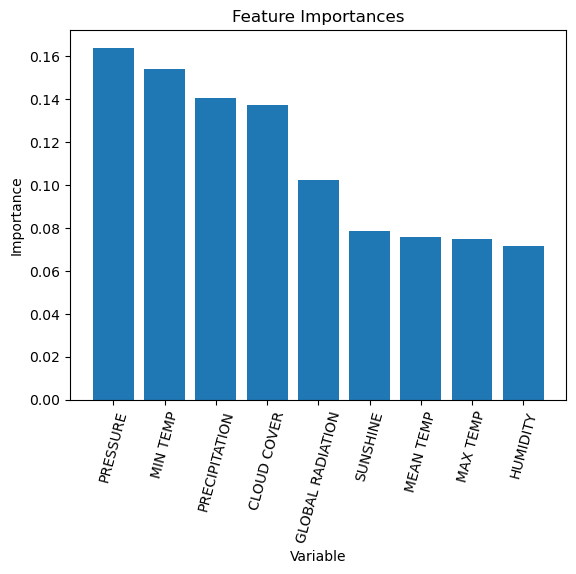

In [43]:
#plot features by importance
print(weatherconditions)
plt.bar(df_important['Weather Condition'], df_important['Importance'], orientation = 'vertical')
plt.xticks(rotation=75, fontsize=10, ha='center')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Feature Importances');
plt.show()

##### Among all stations between 2010 and 2020, precipitation, mean temperature affected the reported pleasantness of the weather the most, followed by global radiation and cloud cover.

#### Importance of Weather Stations on Random Forest

In [46]:
newarray2 = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray2

(135,)


array([4.06266444e-03, 5.61624892e-03, 5.43376291e-03, 6.55589695e-03,
       7.05110130e-03, 8.24654279e-03, 1.69953855e-02, 4.94338619e-03,
       1.75047784e-02, 4.22889839e-03, 5.69198223e-03, 7.05070168e-03,
       5.02405936e-03, 4.36299653e-03, 5.48287758e-03, 1.20139912e-02,
       8.19996932e-03, 1.44127757e-02, 4.19436992e-04, 0.00000000e+00,
       0.00000000e+00, 2.01873460e-03, 4.33304740e-03, 2.17648728e-03,
       2.52822023e-02, 9.65458967e-03, 2.81936550e-02, 3.84966307e-03,
       4.97781490e-03, 6.77115352e-03, 6.29739263e-03, 6.84121763e-03,
       6.46072733e-03, 1.21814160e-02, 5.16345974e-03, 2.23103937e-02,
       3.07791533e-03, 5.00066992e-03, 6.31255908e-03, 6.50831006e-03,
       6.85688880e-03, 6.26807197e-03, 1.04767782e-02, 5.09819122e-03,
       2.89099055e-02, 4.22210090e-03, 6.02789249e-03, 5.79612646e-03,
       8.01440426e-03, 3.57861609e-03, 6.45546079e-03, 1.19929171e-02,
       5.36576698e-03, 1.41268951e-02, 2.79766223e-03, 2.74792201e-03,
      

In [47]:
#reshape feature importance array to show 15 stations, 9 features each
newarray2 = newarray2.reshape(-1,15,9)
print(newarray2.shape)

(1, 15, 9)


In [48]:
#sum values for each station
sumarray2 = np.sum(newarray2[0], axis=1)
sumarray2

array([0.07640977, 0.06646825, 0.07207815, 0.07485324, 0.07850929,
       0.06558018, 0.0258872 , 0.0918113 , 0.07516072, 0.11622963,
       0.07574769, 0.06641974, 0.04910929, 0.04241489, 0.02332066])

In [49]:
#set location names
locations = {
    'BASEL',
    'BELGRADE',
    'BUDAPEST',
    'DEBILT',
    'DUSSELDORF',
    'HEATHROW',
    'KASSEL',
    'LJUBLJANA',
    'MAASTRICHT',
    'MADRID',
    'MUNCHENB',
    'OSLO',
    'SONNBLICK',
    'STOCKHOLM',
    'VALENTIA',
}

In [50]:
#convert array into series
important2 = pd.Series(sumarray2, index = locations)
important2

VALENTIA      0.076410
HEATHROW      0.066468
OSLO          0.072078
BASEL         0.074853
BELGRADE      0.078509
DEBILT        0.065580
LJUBLJANA     0.025887
STOCKHOLM     0.091811
MADRID        0.075161
SONNBLICK     0.116230
MAASTRICHT    0.075748
BUDAPEST      0.066420
MUNCHENB      0.049109
DUSSELDORF    0.042415
KASSEL        0.023321
dtype: float64

In [51]:
#create a dataframe for plotting these features
df_important2 = pd.DataFrame({
    'Weather Station': important2.index,
    'Importance': important2.values
})
df_important2.head

<bound method NDFrame.head of    Weather Station  Importance
0         VALENTIA    0.076410
1         HEATHROW    0.066468
2             OSLO    0.072078
3            BASEL    0.074853
4         BELGRADE    0.078509
5           DEBILT    0.065580
6        LJUBLJANA    0.025887
7        STOCKHOLM    0.091811
8           MADRID    0.075161
9        SONNBLICK    0.116230
10      MAASTRICHT    0.075748
11        BUDAPEST    0.066420
12        MUNCHENB    0.049109
13      DUSSELDORF    0.042415
14          KASSEL    0.023321>

In [52]:
df_important2 = df_important2.sort_values(by='Importance',ascending = False)

In [53]:
df_important2

,Weather Station,Importance
9,SONNBLICK,0.116230
7,STOCKHOLM,0.091811
4,BELGRADE,0.078509
0,VALENTIA,0.076410
10,MAASTRICHT,0.075748
8,MADRID,0.075161
3,BASEL,0.074853
2,OSLO,0.072078
1,HEATHROW,0.066468
11,BUDAPEST,0.066420


{'VALENTIA', 'HEATHROW', 'OSLO', 'BASEL', 'BELGRADE', 'DEBILT', 'LJUBLJANA', 'STOCKHOLM', 'MADRID', 'SONNBLICK', 'MAASTRICHT', 'BUDAPEST', 'MUNCHENB', 'DUSSELDORF', 'KASSEL'}


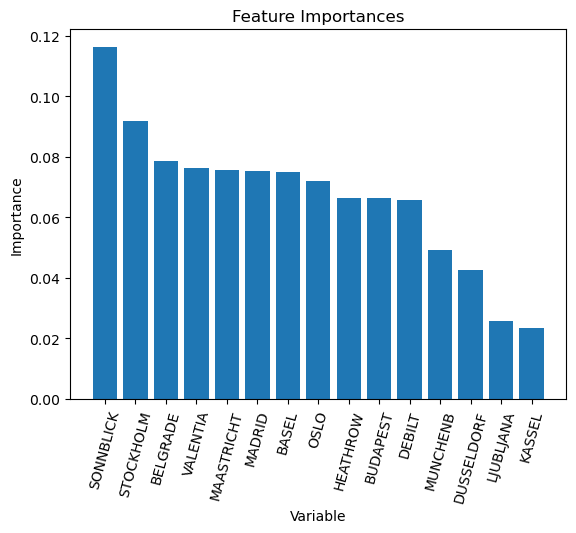

In [54]:
#plot features by importance
print(locations)
plt.bar(df_important2['Weather Station'], df_important2['Importance'], orientation = 'vertical')
plt.xticks(rotation=75, fontsize=10, ha='center')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Feature Importances');
plt.show()